Создаем структуру датасета


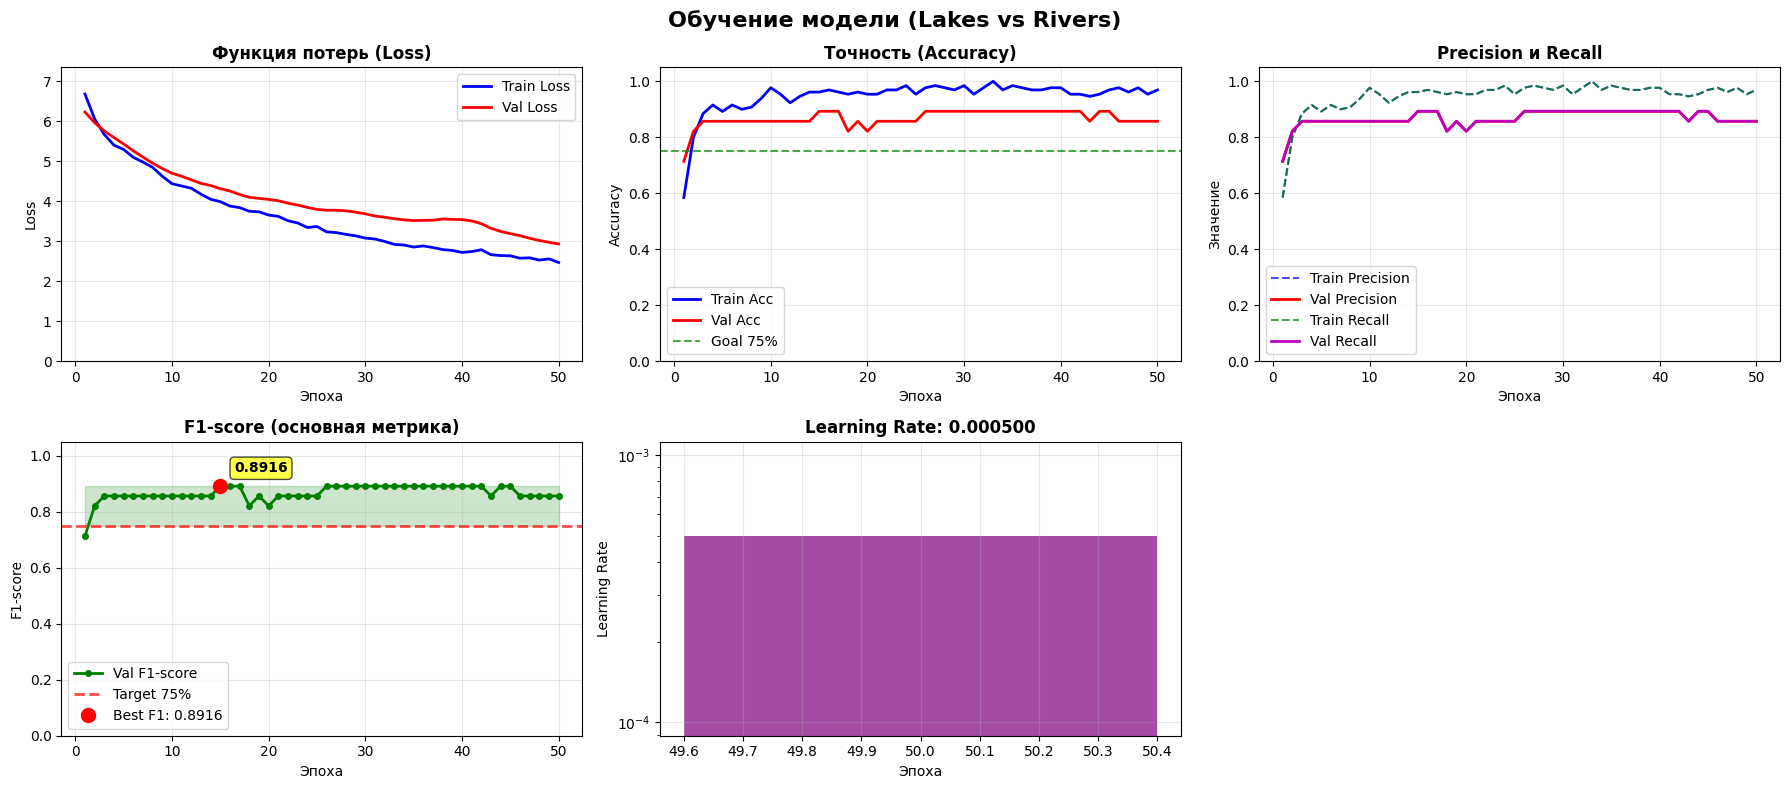


📈 ОБЩАЯ СТАТИСТИКА НА ЭПОХЕ 50:
✅ Лучший F1-score: 0.8916 (эпоха 15)
📊 Прогресс к цели 75%: 100.0%
📊 Цель: ██████████████████████████████ 100.0%


📊 Статистика эпохи 50:
  📉 Train Loss: 2.4681 | Val Loss: 2.9332
  📈 Train Acc: 0.9692 | Val Acc: 0.8571
  🎯 Train Prec: 0.9692 | Val Prec: 0.8571
  🎯 Train Rec: 0.9692 | Val Rec: 0.8571
  ⭐ Val F1-score: 0.8564
  📉 Learning Rate: 0.000500
  🎉 ДОСТИГНУТА ЦЕЛЬ! F1-score ≥ 75% 🎉

🔍 ПРИМЕРЫ ПРЕДСКАЗАНИЙ МОДЕЛИ


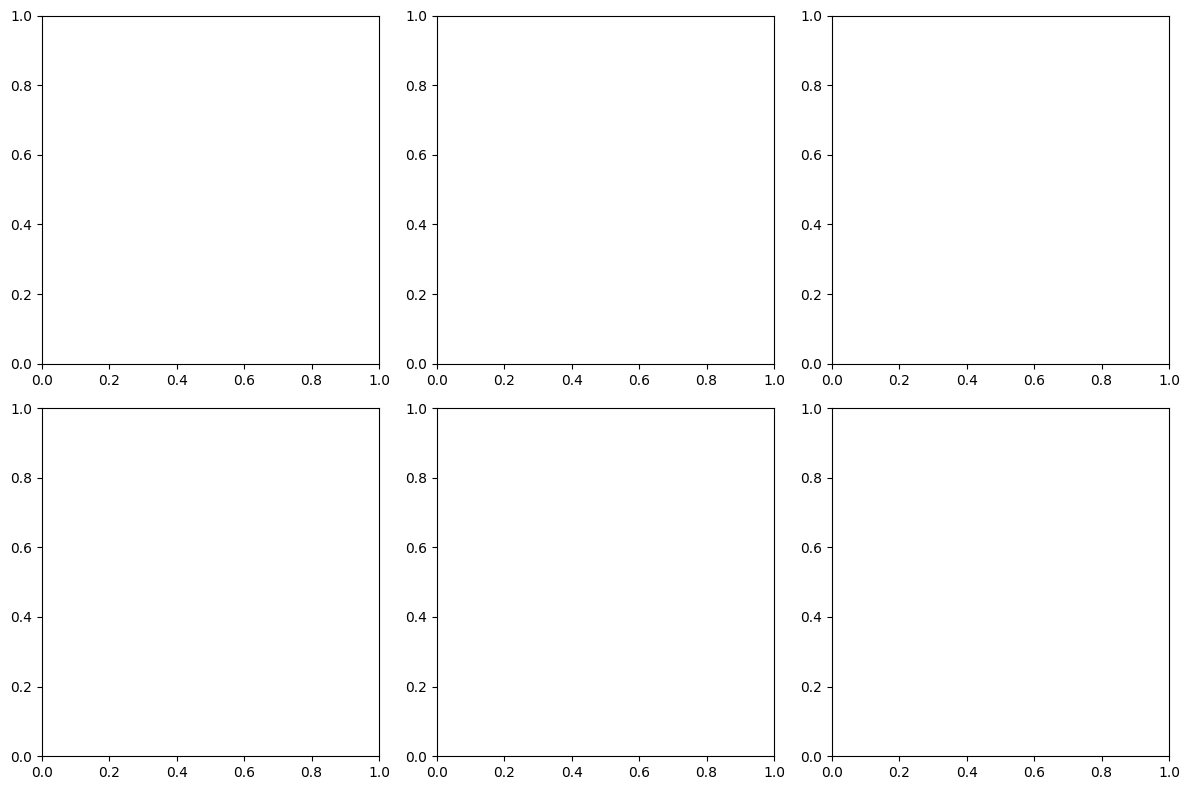


Epoch 50: val_loss improved from 2.97167 to 2.93325, saving model to /content/drive/MyDrive/laba5/best_model_clean.h5



Epoch 50: finished saving model to /content/drive/MyDrive/laba5/best_model_clean.h5
Restoring model weights from the end of the best epoch: 50.

ФИНАЛЬНАЯ ОЦЕНКА МОДЕЛИ
✓ Загружена лучшая модель
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 423ms/step

⏱️  Общее время обучения: 12.46 минут
📈 Финальные метрики:
  • Precision: 0.8646
  • Recall: 0.8571
  • F1-score: 0.8564
  • Accuracy: 0.8571 (85.71%)

=== ДЕТАЛЬНЫЙ ОТЧЕТ ПО КЛАССАМ ===
              precision    recall  f1-score   support

       Озера       0.81      0.93      0.87        14
        Реки       0.92      0.79      0.85        14

    accuracy                           0.86        28
   macro avg       0.86      0.86      0.86        28
weighted avg       0.86      0.86      0.86        28



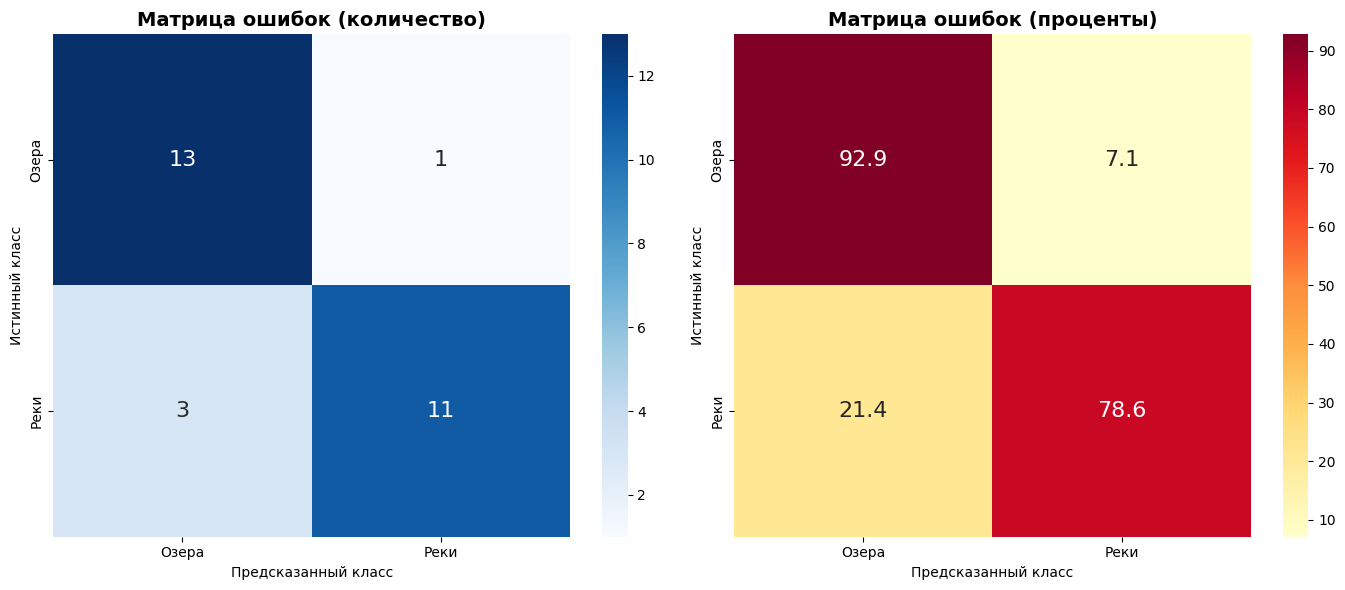

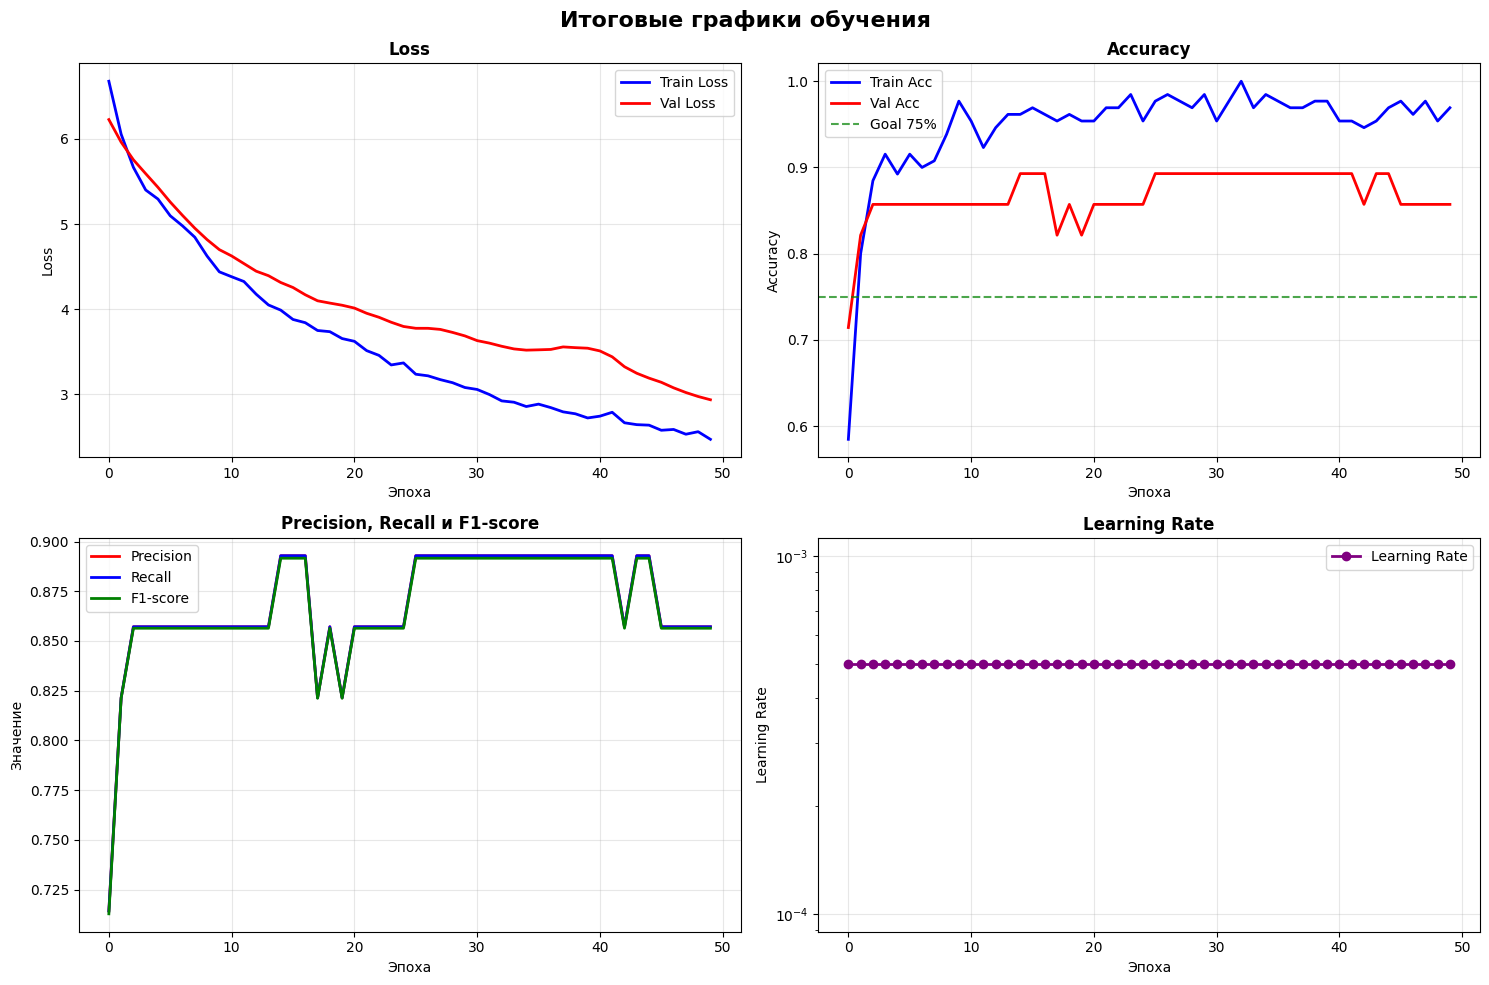


🔍 ФИНАЛЬНЫЕ ПРЕДСКАЗАНИЯ НА ВАЛИДАЦИОННЫХ ДАННЫХ


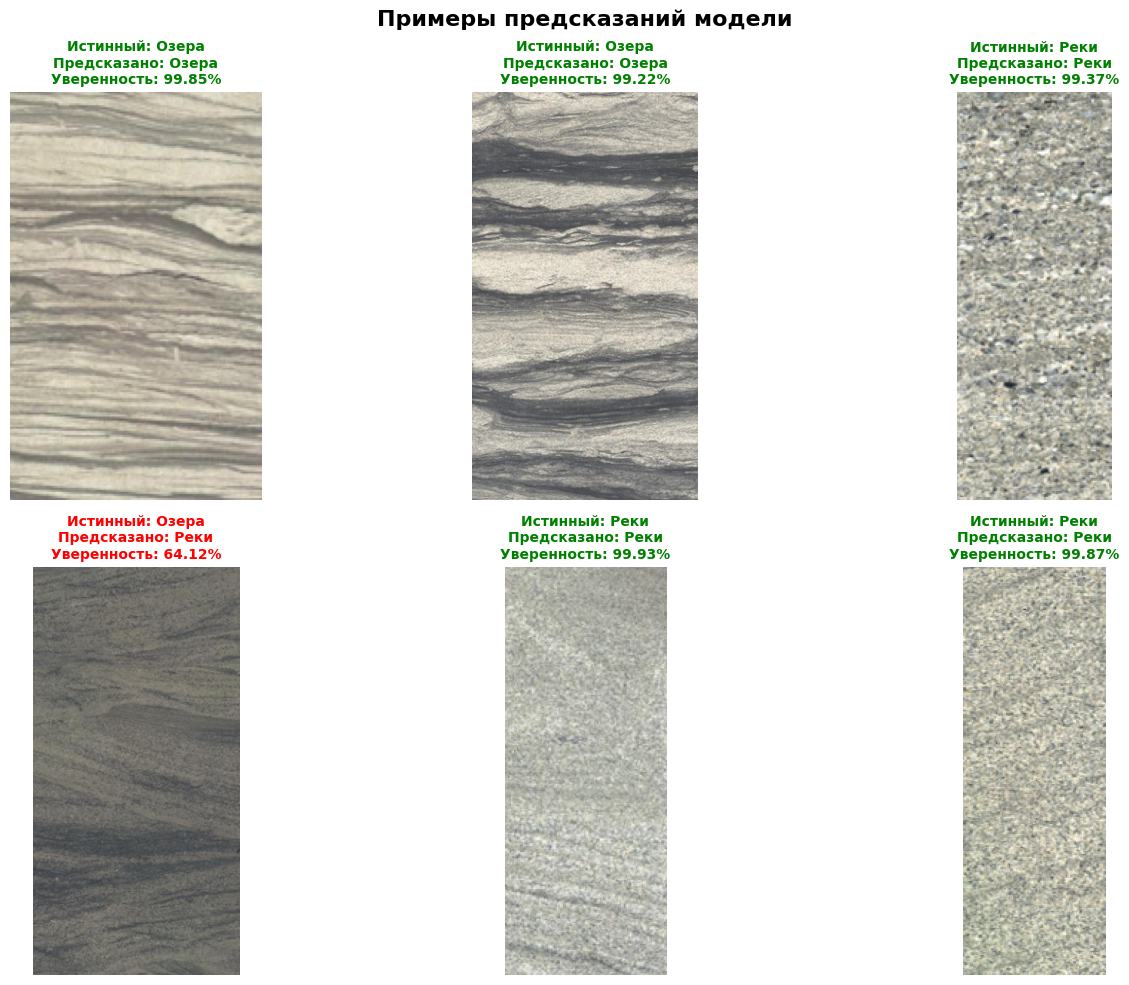


✅ Результаты сохранены в /content/drive/MyDrive/laba5/
✅ Сохраненные файлы:
  • best_model_clean.h5 - лучшая модель
  • confusion_matrix_detailed.png - матрица ошибок
  • final_training_curves.png - итоговые графики
  • predictions_examples.png - примеры предсказаний
  • FINAL_RESULTS.txt - текстовый отчет


In [ ]:
# Установка и импорт библиотек
!pip install tensorflow scikit-learn matplotlib seaborn

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix, classification_report
import os
from google.colab import drive
import time
from IPython.display import clear_output
import random
from PIL import Image

drive.mount('/content/drive')

IMG_SIZE = (224, 224)
BATCH_SIZE = 16
NUM_EPOCHS = 50
CLASSES = ['Lakes', 'Rivers']
CLASS_NAMES_RU = ['Озера', 'Реки']
NUM_CLASSES = len(CLASSES)

dataset_root = '/content/drive/MyDrive/laba5/dataset/'
train_path = os.path.join(dataset_root, 'train')
val_path = os.path.join(dataset_root, 'val')

def show_dataset_samples(path, class_names, samples_per_class=5):
    fig, axes = plt.subplots(len(class_names), samples_per_class, figsize=(15, 6))
    fig.suptitle('Примеры изображений из датасета', fontsize=16, fontweight='bold')

    for i, class_name in enumerate(class_names):
        class_path = os.path.join(path, class_name)
        if os.path.exists(class_path):
            images = [f for f in os.listdir(class_path)
                     if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
            selected = random.sample(images, min(samples_per_class, len(images)))

            for j, img_name in enumerate(selected):
                img_path = os.path.join(class_path, img_name)
                img = plt.imread(img_path)

                if len(class_names) == 2:
                    axes[i, j].imshow(img)
                    axes[i, j].set_title(f'{class_name}', fontsize=10)
                    axes[i, j].axis('off')
                else:
                    axes[j].imshow(img)
                    axes[j].set_title(f'{class_name}', fontsize=10)
                    axes[j].axis('off')

    plt.tight_layout()
    plt.show()

print("="*50)
print("ПРИМЕРЫ ИЗ ОБУЧАЮЩЕЙ ВЫБОРКИ")
print("="*50)
show_dataset_samples(train_path, CLASS_NAMES_RU, samples_per_class=5)

print("\n" + "="*50)
print("ПРИМЕРЫ ИЗ ВАЛИДАЦИОННОЙ ВЫБОРКИ")
print("="*50)
show_dataset_samples(val_path, CLASS_NAMES_RU, samples_per_class=5)

class LiveTrainingVisualization(tf.keras.callbacks.Callback):
    def __init__(self, val_generator, class_names, train_path, val_path):
        super().__init__()
        self.val_generator = val_generator
        self.class_names = class_names
        self.train_path = train_path
        self.val_path = val_path

        # Хранилище метрик
        self.train_losses = []
        self.val_losses = []
        self.train_accs = []
        self.val_accs = []
        self.train_precisions = []
        self.val_precisions = []
        self.train_recalls = []
        self.val_recalls = []
        self.val_f1_scores = []
        self.learning_rates = []

    def on_epoch_begin(self, epoch, logs=None):
        print(f"\n{'='*60}")
        print(f"Эпоха {epoch+1}/{self.params.get('epochs', '?')}")
        print(f"{'='*60}")

    def on_epoch_end(self, epoch, logs=None):
        # Сохраняем метрики
        self.train_losses.append(logs.get('loss', 0))
        self.val_losses.append(logs.get('val_loss', 0))
        self.train_accs.append(logs.get('accuracy', 0))
        self.val_accs.append(logs.get('val_accuracy', 0))
        self.train_precisions.append(logs.get('precision', 0))
        self.val_precisions.append(logs.get('val_precision', 0))
        self.train_recalls.append(logs.get('recall', 0))
        self.val_recalls.append(logs.get('val_recall', 0))

        try:
            lr = self.model.optimizer.learning_rate
            if hasattr(lr, 'numpy'):
                current_lr = lr.numpy()
            elif isinstance(lr, (float, np.float32, np.float64)):
                current_lr = float(lr)
            else:
                current_lr = float(lr)
        except:
            current_lr = 0.0005
        self.learning_rates.append(current_lr)

        self.val_generator.reset()
        preds = self.model.predict(self.val_generator, verbose=0)
        y_pred = np.argmax(preds, axis=1)
        y_true = self.val_generator.classes
        f1 = f1_score(y_true, y_pred, average='weighted')
        self.val_f1_scores.append(f1)

        self.update_plots(epoch)

        print(f"\nСтатистика эпохи {epoch+1}:")
        print(f"  Train Loss: {logs.get('loss', 0):.4f} | Val Loss: {logs.get('val_loss', 0):.4f}")
        print(f"  Train Acc: {logs.get('accuracy', 0):.4f} | Val Acc: {logs.get('val_accuracy', 0):.4f}")
        print(f"  Train Prec: {logs.get('precision', 0):.4f} | Val Prec: {logs.get('val_precision', 0):.4f}")
        print(f"  Train Rec: {logs.get('recall', 0):.4f} | Val Rec: {logs.get('val_recall', 0):.4f}")
        print(f"  Val F1-score: {f1:.4f}")
        print(f"  Learning Rate: {current_lr:.6f}")

        if f1 >= 0.75:
            print(f"F1-score ≥ 75% ")

        # Показываем примеры предсказаний после каждой 5-й эпохи
        if (epoch + 1) % 5 == 0:
            self.show_predictions()

    def update_plots(self, epoch):
        clear_output(wait=True)

        epochs_range = range(1, len(self.train_losses) + 1)

        fig = plt.figure(figsize=(18, 8))
        fig.suptitle('Обучение модели (Lakes vs Rivers)', fontsize=16, fontweight='bold')

        # 1. График Loss
        ax1 = plt.subplot(2, 3, 1)
        ax1.plot(epochs_range, self.train_losses, 'b-', label='Train Loss', linewidth=2)
        ax1.plot(epochs_range, self.val_losses, 'r-', label='Val Loss', linewidth=2)
        ax1.set_title('Функция потерь (Loss)', fontsize=12, fontweight='bold')
        ax1.set_xlabel('Эпоха')
        ax1.set_ylabel('Loss')
        ax1.legend()
        ax1.grid(True, alpha=0.3)
        if self.train_losses and self.val_losses:
            max_loss = max(max(self.train_losses), max(self.val_losses))
            ax1.set_ylim([0, max_loss * 1.1])

        # 2. График Accuracy
        ax2 = plt.subplot(2, 3, 2)
        ax2.plot(epochs_range, self.train_accs, 'b-', label='Train Acc', linewidth=2)
        ax2.plot(epochs_range, self.val_accs, 'r-', label='Val Acc', linewidth=2)
        ax2.axhline(y=0.75, color='g', linestyle='--', label='Goal 75%', alpha=0.7)
        ax2.set_title('Точность (Accuracy)', fontsize=12, fontweight='bold')
        ax2.set_xlabel('Эпоха')
        ax2.set_ylabel('Accuracy')
        ax2.legend()
        ax2.grid(True, alpha=0.3)
        ax2.set_ylim([0, 1.05])

        # 3. График Precision и Recall
        ax3 = plt.subplot(2, 3, 3)
        ax3.plot(epochs_range, self.train_precisions, 'b--', label='Train Precision', linewidth=1.5, alpha=0.7)
        ax3.plot(epochs_range, self.val_precisions, 'r-', label='Val Precision', linewidth=2)
        ax3.plot(epochs_range, self.train_recalls, 'g--', label='Train Recall', linewidth=1.5, alpha=0.7)
        ax3.plot(epochs_range, self.val_recalls, 'm-', label='Val Recall', linewidth=2)
        ax3.set_title('Precision и Recall', fontsize=12, fontweight='bold')
        ax3.set_xlabel('Эпоха')
        ax3.set_ylabel('Значение')
        ax3.legend(loc='best')
        ax3.grid(True, alpha=0.3)
        ax3.set_ylim([0, 1.05])

        # 4. График F1-score (основная метрика)
        ax4 = plt.subplot(2, 3, 4)
        ax4.plot(epochs_range, self.val_f1_scores, 'g-', label='Val F1-score', linewidth=2, marker='o', markersize=4)
        ax4.axhline(y=0.75, color='r', linestyle='--', label='Target 75%', linewidth=2, alpha=0.7)

        # Закрашиваем область выше цели
        if self.val_f1_scores and max(self.val_f1_scores) >= 0.75:
            ax4.fill_between(epochs_range, 0.75, max(self.val_f1_scores), alpha=0.2, color='green')

        # Отмечаем лучший F1
        if self.val_f1_scores:
            best_f1 = max(self.val_f1_scores)
            best_epoch = np.argmax(self.val_f1_scores) + 1
            ax4.plot(best_epoch, best_f1, 'ro', markersize=10, label=f'Best F1: {best_f1:.4f}')
            ax4.annotate(f'{best_f1:.4f}',
                        xy=(best_epoch, best_f1),
                        xytext=(10, 10),
                        textcoords='offset points',
                        fontsize=10,
                        fontweight='bold',
                        bbox=dict(boxstyle='round,pad=0.3', facecolor='yellow', alpha=0.7))

        ax4.set_title('F1-score (основная метрика)', fontsize=12, fontweight='bold')
        ax4.set_xlabel('Эпоха')
        ax4.set_ylabel('F1-score')
        ax4.legend(loc='best')
        ax4.grid(True, alpha=0.3)
        ax4.set_ylim([0, 1.05])

        # 5. График Learning Rate
        ax5 = plt.subplot(2, 3, 5)
        if self.learning_rates:
            current_lr = self.learning_rates[-1]
            ax5.bar(epoch + 1, current_lr, color='purple', alpha=0.7, width=0.8)
            ax5.set_title(f'Learning Rate: {current_lr:.6f}', fontsize=12, fontweight='bold')
        else:
            ax5.set_title('Learning Rate', fontsize=12, fontweight='bold')
        ax5.set_xlabel('Эпоха')
        ax5.set_ylabel('Learning Rate')
        ax5.set_yscale('log')
        ax5.grid(True, alpha=0.3)

        plt.tight_layout()
        plt.show()

        # Выводим общую статистику
        if self.val_f1_scores:
            best_f1 = max(self.val_f1_scores)
            best_epoch = np.argmax(self.val_f1_scores) + 1
            print(f"\n{'='*60}")
            print(f"ОБЩАЯ СТАТИСТИКА НА ЭПОХЕ {epoch+1}:")
            print(f"{'='*60}")
            print(f"Лучший F1-score: {best_f1:.4f} (эпоха {best_epoch})")
            print(f"Прогресс к цели 75%: {min(100, (best_f1/0.75)*100):.1f}%")

            progress = min(100, (best_f1/0.75)*100)
            bar_length = 30
            filled = int(bar_length * progress // 100)
            bar = '█' * filled + '░' * (bar_length - filled)
            print(f"📊 Цель: {bar} {progress:.1f}%")

            # Предупреждение о переобучении
            if len(self.train_losses) > 5 and len(self.val_losses) > 5:
                if self.val_losses[-1] > self.val_losses[-2] and self.train_losses[-1] < self.train_losses[-2]:
                    print(f"Val loss растет, Train loss падает.")

            print(f"{'='*60}\n")

    def show_predictions(self, num_samples=6):
        print("\n" + "="*60)
        print("ПРИМЕРЫ ПРЕДСКАЗАНИЙ МОДЕЛИ")
        print("="*60)

        # Берем случайные изображения из валидации
        val_files = []
        val_labels = []
        for class_idx, class_name in enumerate(self.class_names):
            class_path = os.path.join(self.val_path, class_name)
            if os.path.exists(class_path):
                images = [os.path.join(class_path, f) for f in os.listdir(class_path)
                         if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
                val_files.extend(images)
                val_labels.extend([class_idx] * len(images))

        # Выбираем случайные
        indices = random.sample(range(len(val_files)), min(num_samples, len(val_files)))

        fig, axes = plt.subplots(2, 3, figsize=(12, 8))
        axes = axes.flatten()

        for i, idx in enumerate(indices):
            img_path = val_files[idx]
            true_label = val_labels[idx]

            # Загружаем и предсказываем
            img = Image.open(img_path).convert('RGB')
            img_resized = img.resize(IMG_SIZE)
            img_array = np.array(img_resized) / 255.0
            img_batch = np.expand_dims(img_array, axis=0)

            pred = self.model.predict(img_batch, verbose=0)
            pred_class = np.argmax(pred[0])
            confidence = pred[0][pred_class]

            # Отображаем
            axes[i].imshow(img)
            color = 'green' if pred_class == true_label else 'red'
            title = f'True: {self.class_names[true_label]}\nPred: {self.class_names[pred_class]}\nConf: {confidence:.2%}'
            axes[i].set_title(title, color=color, fontsize=10)
            axes[i].axis('off')

        plt.tight_layout()
        plt.show()

print("\n" + "="*50)
print("СТАТИСТИКА ДАННЫХ")
print("="*50)

for split_name, split_path in [('TRAIN', train_path), ('VAL', val_path)]:
    print(f"\n{split_name}:")
    for class_name in CLASSES:
        class_path = os.path.join(split_path, class_name)
        if os.path.exists(class_path):
            count = len([f for f in os.listdir(class_path)
                        if f.lower().endswith(('.png', '.jpg', '.jpeg'))])
            print(f"  {class_name}: {count}")

print("\n" + "="*50)
print("ЗАГРУЗКА ДАННЫХ")
print("="*50)

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=25,
    width_shift_range=0.15,
    height_shift_range=0.15,
    shear_range=0.15,
    zoom_range=0.15,
    horizontal_flip=True,
    vertical_flip=True,
    brightness_range=[0.8, 1.2],
    fill_mode='nearest'
)

val_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    train_path,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    classes=CLASSES,
    shuffle=True,
    seed=42
)

val_generator = val_datagen.flow_from_directory(
    val_path,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    classes=CLASSES,
    shuffle=False,
    seed=42
)

print(f"\nОбучающих изображений: {train_generator.samples}")
print(f"Валидационных изображений: {val_generator.samples}")

print("\n" + "="*50)
print("ПОСТРОЕНИЕ МОДЕЛИ")
print("="*50)

base_model = MobileNetV2(
    include_top=False,
    weights='imagenet',
    input_shape=(224, 224, 3)
)
base_model.trainable = False

model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(256, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(0.01)),
    layers.BatchNormalization(),
    layers.Dropout(0.5),
    layers.Dense(128, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(0.01)),
    layers.BatchNormalization(),
    layers.Dropout(0.4),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(NUM_CLASSES, activation='softmax')
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0005),
    loss='categorical_crossentropy',
    metrics=['accuracy',
             tf.keras.metrics.Precision(name='precision'),
             tf.keras.metrics.Recall(name='recall')]
)

model.summary()

live_viz = LiveTrainingVisualization(val_generator, CLASS_NAMES_RU, train_path, val_path)

early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=15,
    mode='min',
    restore_best_weights=True,
    verbose=1
)

reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=7,
    min_lr=1e-7,
    verbose=1
)

checkpoint = tf.keras.callbacks.ModelCheckpoint(
    '/content/drive/MyDrive/laba5/best_model_clean.h5',
    monitor='val_loss',
    save_best_only=True,
    mode='min',
    verbose=1
)

print("\n" + "="*50)
print("НАЧАЛО ОБУЧЕНИЯ")
print("="*50)

start_time = time.time()

history = model.fit(
    train_generator,
    epochs=NUM_EPOCHS,
    validation_data=val_generator,
    callbacks=[early_stop, reduce_lr, live_viz, checkpoint],
    verbose=0
)

training_time = time.time() - start_time

print("\n" + "="*50)
print("ФИНАЛЬНАЯ ОЦЕНКА МОДЕЛИ")
print("="*50)

# Загружаем лучшую модель
if os.path.exists('/content/drive/MyDrive/laba5/best_model_clean.h5'):
    model.load_weights('/content/drive/MyDrive/laba5/best_model_clean.h5')
    print("Загружена лучшая модель")

# Финальное предсказание
val_generator.reset()
preds = model.predict(val_generator)
y_pred = np.argmax(preds, axis=1)
y_true = val_generator.classes

# Метрики
final_precision = precision_score(y_true, y_pred, average='weighted')
final_recall = recall_score(y_true, y_pred, average='weighted')
final_f1 = f1_score(y_true, y_pred, average='weighted')
final_accuracy = np.mean(y_true == y_pred)

print(f"\nОбщее время обучения: {training_time/60:.2f} минут")
print(f"Финальные метрики:")
print(f"  Precision: {final_precision:.4f}")
print(f"  Recall: {final_recall:.4f}")
print(f"  F1-score: {final_f1:.4f}")
print(f"  Accuracy: {final_accuracy:.4f} ({final_accuracy:.2%})")

print("\nОТЧЕТ ПО КЛАССАМ")
print(classification_report(y_true, y_pred, target_names=CLASS_NAMES_RU))

# Матрица ошибок с процентами
cm = confusion_matrix(y_true, y_pred)
cm_percent = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Абсолютные значения
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASS_NAMES_RU, yticklabels=CLASS_NAMES_RU,
            annot_kws={'size': 16}, ax=ax1)
ax1.set_title('Матрица ошибок (количество)', fontsize=14, fontweight='bold')
ax1.set_ylabel('Истинный класс')
ax1.set_xlabel('Предсказанный класс')

# Проценты
sns.heatmap(cm_percent, annot=True, fmt='.1f', cmap='YlOrRd',
            xticklabels=CLASS_NAMES_RU, yticklabels=CLASS_NAMES_RU,
            annot_kws={'size': 16}, ax=ax2)
ax2.set_title('Матрица ошибок (проценты)', fontsize=14, fontweight='bold')
ax2.set_ylabel('Истинный класс')
ax2.set_xlabel('Предсказанный класс')

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/laba5/confusion_matrix_detailed.png', dpi=150)
plt.show()

# Финальные графики всех метрик
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle('Итоговые графики обучения', fontsize=16, fontweight='bold')

# Loss
axes[0, 0].plot(live_viz.train_losses, 'b-', label='Train Loss', linewidth=2)
axes[0, 0].plot(live_viz.val_losses, 'r-', label='Val Loss', linewidth=2)
axes[0, 0].set_title('Loss', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Эпоха')
axes[0, 0].set_ylabel('Loss')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Accuracy
axes[0, 1].plot(live_viz.train_accs, 'b-', label='Train Acc', linewidth=2)
axes[0, 1].plot(live_viz.val_accs, 'r-', label='Val Acc', linewidth=2)
axes[0, 1].axhline(y=0.75, color='g', linestyle='--', label='Goal 75%', alpha=0.7)
axes[0, 1].set_title('Accuracy', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('Эпоха')
axes[0, 1].set_ylabel('Accuracy')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Precision & Recall
axes[1, 0].plot(live_viz.val_precisions, 'r-', label='Precision', linewidth=2)
axes[1, 0].plot(live_viz.val_recalls, 'b-', label='Recall', linewidth=2)
axes[1, 0].plot(live_viz.val_f1_scores, 'g-', label='F1-score', linewidth=2)
axes[1, 0].set_title('Precision, Recall и F1-score', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('Эпоха')
axes[1, 0].set_ylabel('Значение')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# Learning Rate
axes[1, 1].plot(live_viz.learning_rates, 'purple', label='Learning Rate', linewidth=2, marker='o')
axes[1, 1].set_title('Learning Rate', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('Эпоха')
axes[1, 1].set_ylabel('Learning Rate')
axes[1, 1].set_yscale('log')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/laba5/final_training_curves.png', dpi=150)
plt.show()

# Показываем финальные предсказания
print("\n" + "="*60)
print("ФИНАЛЬНЫЕ ПРЕДСКАЗАНИЯ НА ВАЛИДАЦИОННЫХ ДАННЫХ")
print("="*60)

# Берем случайные изображения из валидации
val_files = []
val_labels = []
for class_idx, class_name in enumerate(CLASS_NAMES_RU):
    class_path = os.path.join(val_path, CLASSES[class_idx])
    if os.path.exists(class_path):
        images = [os.path.join(class_path, f) for f in os.listdir(class_path)
                 if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
        val_files.extend(images)
        val_labels.extend([class_idx] * len(images))

# Выбираем 6 случайных изображений
indices = random.sample(range(len(val_files)), min(6, len(val_files)))

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for i, idx in enumerate(indices):
    img_path = val_files[idx]
    true_label = val_labels[idx]

    # Загружаем и предсказываем
    img = Image.open(img_path).convert('RGB')
    img_resized = img.resize(IMG_SIZE)
    img_array = np.array(img_resized) / 255.0
    img_batch = np.expand_dims(img_array, axis=0)

    pred = model.predict(img_batch, verbose=0)
    pred_class = np.argmax(pred[0])
    confidence = pred[0][pred_class]

    # Отображаем
    axes[i].imshow(img)
    color = 'green' if pred_class == true_label else 'red'
    title = f'Истинный: {CLASS_NAMES_RU[true_label]}\nПредсказано: {CLASS_NAMES_RU[pred_class]}\nУверенность: {confidence:.2%}'
    axes[i].set_title(title, color=color, fontsize=10, fontweight='bold')
    axes[i].axis('off')

plt.suptitle('Примеры предсказаний модели', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/laba5/predictions_examples.png', dpi=150)
plt.show()

# Сохраняем результаты
with open('/content/drive/MyDrive/laba5/FINAL_RESULTS.txt', 'w', encoding='utf-8') as f:
    f.write("ФИНАЛЬНЫЕ РЕЗУЛЬТАТЫ ОБУЧЕНИЯ\n")
    f.write("="*50 + "\n")
    f.write(f"Время обучения: {training_time/60:.2f} минут\n")
    f.write(f"Количество эпох: {len(live_viz.train_losses)}\n")
    if live_viz.val_f1_scores:
        f.write(f"Лучший F1-score: {max(live_viz.val_f1_scores):.4f}\n\n")
    f.write("МЕТРИКИ НА ВАЛИДАЦИИ:\n")
    f.write(f"Precision: {final_precision:.4f}\n")
    f.write(f"Recall: {final_recall:.4f}\n")
    f.write(f"F1-score: {final_f1:.4f}\n")
    f.write(f"Accuracy: {final_accuracy:.4f}\n\n")
    f.write("ОТЧЕТ ПО КЛАССАМ:\n")
    f.write(classification_report(y_true, y_pred, target_names=CLASS_NAMES_RU))

print("\nРезультаты сохранены в /content/drive/MyDrive/laba5/")
print("Сохраненные файлы:")
print("best_model_clean.h5 - лучшая модель")
print("confusion_matrix_detailed.png - матрица ошибок")
print("final_training_curves.png - итоговые графики")
print("predictions_examples.png - примеры предсказаний")
print("FINAL_RESULTS.txt - текстовый отчет")